# PAMAP2 Zero‑Shot Learning (ZSL) — **Explainable** Notebook
## Contrastive ZSL + Transformer Label Embeddings + Prototype Refinement + Rich EDA

**What you asked for:** more EDA, more visualisations, clearer per‑epoch logging, and explanations of what each cell is doing.

This notebook is self‑contained and reproducible. It keeps the **same data extraction / folder structure**:

```
PAMAP2_Dataset/
  Protocol/ subject1.dat ... subject9.dat
  Optional/ subject1.dat ... subject9.dat
```

### Pipeline (high level)
1. Load Protocol + Optional data
2. Clean + impute missing values (per subject/session)
3. Create fixed‑length windows + purity filtering (remove transition windows)
4. Split into:
   - **Train/Val:** SEEN classes only  
   - **Test:** UNSEEN classes only
5. Build **label prototypes** using a pretrained transformer (Sentence‑BERT)
6. Train a time‑series encoder (TCN) with **contrastive loss over prototypes**
7. Evaluate ZSL:
   - Baseline nearest‑prototype
   - **Prototype refinement** (pseudo‑label transductive refinement)
8. Visualise:
   - Label distributions, missingness, window purity
   - Example sensor windows
   - Label‑prototype similarity heatmap
   - t‑SNE: prototypes + unseen window embeddings

> Timestamp: 2026-01-23T04:17:38

## 0) Setup

This cell:
- imports libraries
- sets random seeds (reproducible)
- chooses GPU if available
- applies two practical macOS/Jupyter fixes:
  - `TOKENIZERS_PARALLELISM=false` (silences HuggingFace fork warning)
  - `num_workers=0` for DataLoader (avoids spawn/pickling issues)

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# --- macOS/Jupyter stability ---
os.environ["TOKENIZERS_PARALLELISM"] = "false"
NUM_WORKERS = 0

DEVICE: cpu


## 1) Activity IDs + official descriptions (semantic text)

This defines:
- PAMAP2 activity IDs → names
- **official descriptions** (your provided text)

These descriptions are embedded using a pretrained transformer to create **label prototypes**.

In [2]:
ACTIVITY_MAP = {
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "Nordic walking",
    9: "watching TV",
    10: "computer work",
    11: "car driving",
    12: "ascending stairs",
    13: "descending stairs",
    16: "vacuum cleaning",
    17: "ironing",
    18: "folding laundry",
    19: "house cleaning",
    20: "playing soccer",
    24: "rope jumping",
}

LABEL_TEXT = {
    1:  "lying quietly while doing nothing; small movements allowed (e.g., changing posture)",
    2:  "sitting in a chair in any comfortable posture; changing sitting postures allowed",
    3:  "standing still or standing and talking; gesticulating possible",
    17: "ironing 1-2 shirts or T-shirts",
    16: "vacuum cleaning one or two rooms; includes moving objects (e.g., chairs) on the floor",
    12: "ascending stairs across multiple floors (five floors) going upstairs",
    13: "descending stairs across multiple floors (five floors) going downstairs",
    4:  "walking outside with moderate to brisk pace (4-6 km/h)",
    7:  "Nordic walking outside using poles; subjects not very familiar with the activity",
    6:  "cycling outside with real bike at slow to moderate pace (not sport pace)",
    5:  "running/jogging outside at a suitable speed for the subject",
    24: "rope jumping; basic jump or alternate foot jump; repeated vertical jumps",
    9:  "watching TV at home; posture can be lying or sitting",
    10: "computer work; working normally in the office",
    11: "car driving between office and home",
    18: "folding shirts, T-shirts and/or bed linens",
    19: "house cleaning; dusting shelves; removing books/things and putting them back",
    20: "playing soccer 1v1 or 2v1; running with ball, dribbling, passing, shooting",
}

## 2) Load PAMAP2 Protocol + Optional (data extraction unchanged)

This cell:
- defines the 54 raw column names (timestamp, label, HR, 3 IMUs × 17 channels)
- reads `subject*.dat` from `Protocol/` and `Optional/`
- concatenates everything into one table

In [3]:
DATA_ROOT = "PAMAP2_Dataset"  # change if needed

def make_colnames():
    cols = ["timestamp", "label", "hr"]
    imu_parts = [
        "temp",
        "acc16_x","acc16_y","acc16_z",
        "acc6_x","acc6_y","acc6_z",
        "gyro_x","gyro_y","gyro_z",
        "mag_x","mag_y","mag_z",
        "ori_1","ori_2","ori_3","ori_4",
    ]
    for loc in ["hand","chest","ankle"]:
        cols += [f"{loc}_{p}" for p in imu_parts]
    assert len(cols) == 54
    return cols

COLS = make_colnames()

def load_all_sessions(data_root=DATA_ROOT):
    dfs = []
    for part in ["Protocol","Optional"]:
        folder = os.path.join(data_root, part)
        for f in sorted(glob.glob(os.path.join(folder, "subject*.dat"))):
            df = pd.read_csv(f, sep=r"\s+", header=None, names=COLS, engine="python")
            df["session"] = part.lower()
            df["subject"] = os.path.splitext(os.path.basename(f))[0]  # e.g., subject1
            dfs.append(df)
    if not dfs:
        raise FileNotFoundError("No subject*.dat found. Check DATA_ROOT/Protocol and DATA_ROOT/Optional.")
    return pd.concat(dfs, ignore_index=True)

raw = load_all_sessions()
print("Raw shape:", raw.shape)
raw.head(2)

KeyboardInterrupt: 

## 3) Quick EDA on raw data

We look at:
- available labels
- sessions/subjects
- missingness rate (NaNs are expected in PAMAP2)

In [5]:
print("Subjects:", raw["subject"].nunique(), "| Sessions:", raw["session"].unique())
print("Unique labels (raw):", sorted(raw["label"].dropna().unique().astype(int).tolist())[:30], "...")
print("Overall NaN fraction (raw):", float(raw.isna().mean().mean()))

# How much label==0 exists (transient)
if "label" in raw.columns:
    z0 = (raw["label"] == 0).mean()
    print("Transient label==0 fraction:", float(z0))

Subjects: 9 | Sessions: ['protocol' 'optional']
Unique labels (raw): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24] ...
Overall NaN fraction (raw): 0.018765720340578707
Transient label==0 fraction: 0.29231282649938123


### Visualisation 3A — Missing values by column (top 25)

This helps you see which sensors/channels are missing often.

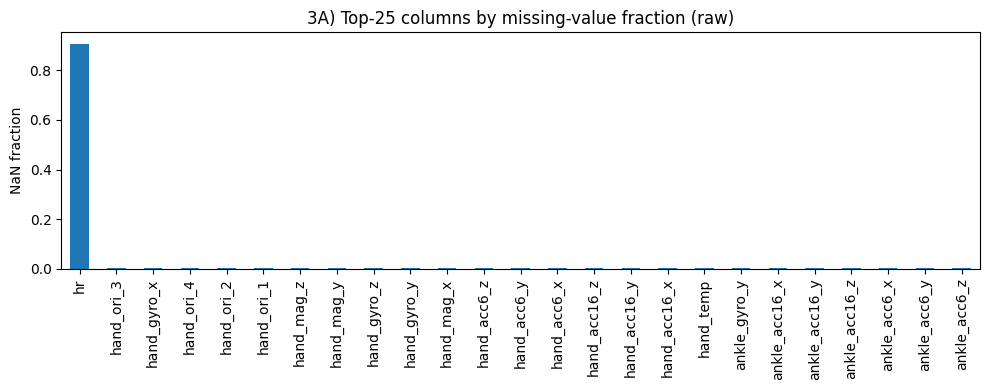

In [6]:
nan_by_col = raw.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
nan_by_col.head(25).plot(kind="bar")
plt.title("3A) Top-25 columns by missing-value fraction (raw)")
plt.ylabel("NaN fraction")
plt.tight_layout()
plt.show()

## 4) Preprocess (impute NaNs; drop transient label 0; drop invalid orientation; drop acc6)

Why:
- orientation channels are invalid in this dataset
- acc6 sometimes saturates; PAMAP2 recommends using acc16
- we **impute** missing values per subject/session to avoid dropping everything

Outputs:
- `df`: cleaned dataframe
- `FEATURE_COLS`: list of numeric features used by the model

In [7]:
ORI_COLS  = [c for c in COLS if "_ori_" in c]
ACC6_COLS = [c for c in COLS if "_acc6_" in c]

def preprocess_pamap2(df: pd.DataFrame,
                      drop_orientation: bool = True,
                      drop_acc6: bool = True,
                      keep_hr: bool = True,
                      max_nan_frac_per_row: float = 0.30) -> pd.DataFrame:
    df = df.copy()

    # Ensure numeric label
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)

    # Drop transient
    df = df[df["label"] != 0].reset_index(drop=True)

    # Drop problematic channels
    if drop_orientation:
        df = df.drop(columns=ORI_COLS, errors="ignore")
    if drop_acc6:
        df = df.drop(columns=ACC6_COLS, errors="ignore")
    if not keep_hr:
        df = df.drop(columns=["hr"], errors="ignore")

    # Force numeric for features
    for c in df.columns:
        if c not in ["subject","session"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    feat_cols = [c for c in df.columns if c not in ["subject","session","label"]]

    # Impute within each subject/session in time order
    def impute_group(g):
        g = g.sort_values("timestamp")
        g[feat_cols] = g[feat_cols].interpolate(limit_direction="both")
        g[feat_cols] = g[feat_cols].ffill().bfill()
        return g

    df = df.groupby(["subject","session"], group_keys=False).apply(impute_group)

    # Drop rows with excessive missingness (after interpolation)
    nan_frac = df[feat_cols].isna().mean(axis=1)
    df = df[nan_frac <= max_nan_frac_per_row].reset_index(drop=True)

    df = df.dropna().reset_index(drop=True)
    return df

df = preprocess_pamap2(raw)
print("Preprocessed shape:", df.shape)
df.head(2)

Preprocessed shape: (2724953, 35)


,timestamp,label,hr,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,...,ankle_acc16_y,ankle_acc16_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,session,subject
0,37.66,1,100.0,30.375,2.21530,8.27915,5.58753,-0.00475,0.037579,-0.011145,...,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.8636,-58.3696,protocol,subject101
1,37.67,1,100.0,30.375,2.29196,7.67288,5.74467,-0.17171,0.025479,-0.009538,...,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.3197,-58.3656,protocol,subject101


### Visualisation 4A — Label distribution after preprocessing

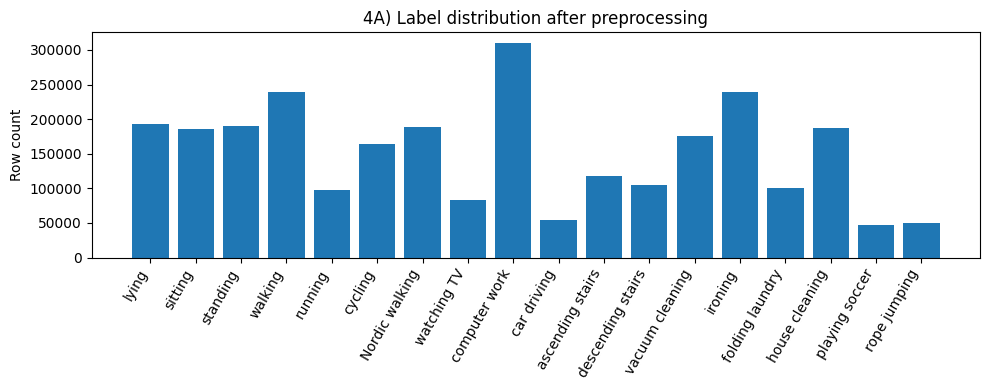

In [8]:
label_counts = df["label"].value_counts().sort_index()
names = [ACTIVITY_MAP.get(i, str(i)) for i in label_counts.index]

plt.figure(figsize=(10,4))
plt.bar(range(len(label_counts)), label_counts.values)
plt.xticks(range(len(label_counts)), names, rotation=60, ha="right")
plt.title("4A) Label distribution after preprocessing")
plt.ylabel("Row count")
plt.tight_layout()
plt.show()

## 5) Windowing + purity filtering

We convert the continuous streams into fixed-length examples:
- Window size = 5s at 100Hz → 500 samples (default)
- Stride = 250 (50% overlap)
- Purity filter keeps windows where the majority label dominates ≥ threshold

This reduces label noise (especially around transitions).

In [9]:
FEATURE_COLS = [c for c in df.columns if c not in ["subject","session","label"]]

WINDOW_SIZE_TRAIN = 500 
WINDOW_SIZE_TEST=1000
# STRIDE = 250
STRIDE_TRAIN = 250
STRIDE_TEST  = 500
PURITY_THRESH = 0.80

# def make_windows(df: pd.DataFrame, feature_cols, window_size, stride, purity_thresh):
#     X, y, purity, meta = [], [], [], []
#     for (subject, session), g in df.groupby(["subject","session"]):
#         g = g.sort_values("timestamp")
#         values = g[feature_cols].to_numpy(dtype=np.float32)
#         labels = g["label"].to_numpy(dtype=np.int64)
#         n = len(g)
#         for start in range(0, n - window_size + 1, stride):
#             end = start + window_size
#             wlab = labels[start:end]
#             binc = np.bincount(wlab)
#             maj = int(binc.argmax())
#             pur = float(binc.max()) / float(window_size)
#             if pur < purity_thresh:
#                 continue
#             X.append(values[start:end])
#             y.append(maj)
#             purity.append(pur)
#             meta.append((subject, session))
#     X = np.stack(X) if X else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
#     y = np.array(y, dtype=np.int64)
#     purity = np.array(purity, dtype=np.float32)
#     meta = pd.DataFrame(meta, columns=["subject","session"])
#     return X, y, purity, meta

def make_windows(df: pd.DataFrame, feature_cols, window_size, stride, purity_thresh):
    X, y, pur, meta = [], [], [], []
    for (subject, session), g in df.groupby(["subject","session"]):
        g = g.sort_values("timestamp")
        values = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy(dtype=np.int64)
        n = len(g)
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            wlab = labels[start:end]
            binc = np.bincount(wlab)
            maj = int(binc.argmax())
            purity = float(binc.max()) / float(window_size)
            if purity < purity_thresh:
                continue
            X.append(values[start:end])
            y.append(maj)
            pur.append(purity)
            meta.append((subject, session))
    X = np.stack(X) if X else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    pur = np.array(pur, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["subject","session"])
    return X, y, pur, meta

# X, y, pur, meta = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE, PURITY_THRESH)
# print("Windows:", X.shape, y.shape)
# print("Purity: min/mean/max =", float(pur.min()), float(pur.mean()), float(pur.max()))

# 500-sample windows for training/validation
X_trw, y_trw, pur_tr, meta_tr = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE_TRAIN, PURITY_THRESH)

# 1000-sample windows for ZSL testing
X_tew, y_tew, pur_te, meta_te = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TEST,  STRIDE_TEST,  PURITY_THRESH)

print("Train/Val windows (500):", X_trw.shape, y_trw.shape, "| purity mean:", float(pur_tr.mean()) if len(pur_tr) else None)
print("Test windows   (1000):", X_tew.shape, y_tew.shape, "| purity mean:", float(pur_te.mean()) if len(pur_te) else None)



Train/Val windows (500): (10753, 500, 32) (10753,) | purity mean: 0.9991695880889893
Test windows   (1000): (5288, 1000, 32) (5288,) | purity mean: 0.9984428882598877


### Visualisation 5A — Purity histogram

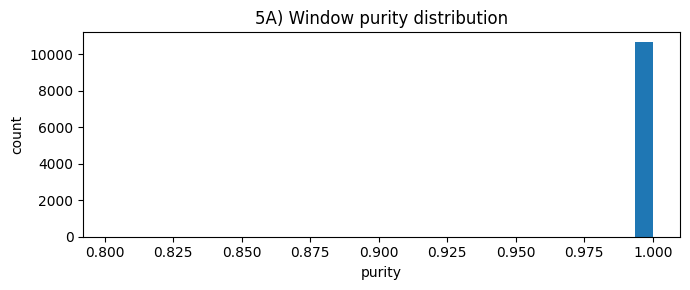

In [10]:
plt.figure(figsize=(7,3))
plt.hist(pur_tr, bins=30)
plt.title("5A) Window purity distribution")
plt.xlabel("purity")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Visualisation 5B — Example window plot (sanity check)

We plot a few sensor channels for a random window, just to verify signals look reasonable.

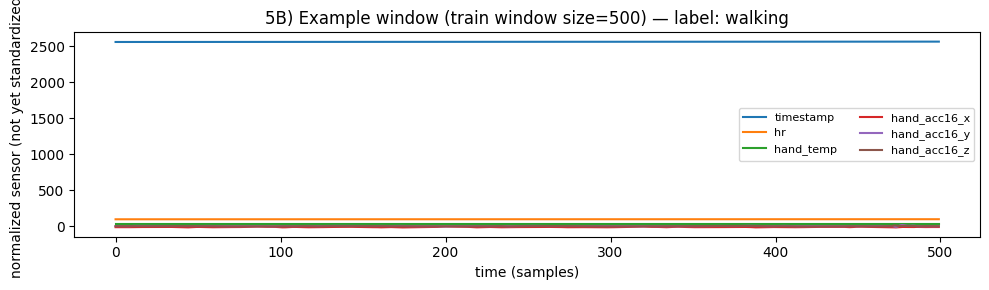

In [11]:
if len(X_trw) > 0:
    idx = np.random.randint(0, len(X_trw))
    plt.figure(figsize=(10,3))
    for ch in range(min(6, X_trw.shape[-1])):
        plt.plot(X_trw[idx, :, ch], label=FEATURE_COLS[ch])
    plt.title(f"5B) Example window (train window size={WINDOW_SIZE_TRAIN}) — label: {ACTIVITY_MAP.get(int(y_trw[idx]), y_trw[idx])}")
    plt.xlabel("time (samples)")
    plt.ylabel("normalized sensor (not yet standardized)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 6) Train/Val/Test split + summary statistics

We do a **subject split**:
- reserve the last 2 subjects for testing (new people)
- training uses the remaining subjects

Then we enforce ZSL:
- Train/Val: **SEEN** classes only
- Test: **UNSEEN** classes only

This cell prints counts so you can track class imbalance and dataset size.

In [12]:
UNSEEN = [5,13,16,18] 
ALL_LABELS = sorted(set(y_trw.tolist() + y_tew.tolist()))
UNSEEN = [l for l in UNSEEN if l in ALL_LABELS]
SEEN = [l for l in ALL_LABELS if l not in UNSEEN]

# subject split using TRAIN-window metadata (meta_tr)
subjects = sorted(meta_tr["subject"].unique())
test_subjects = subjects[-2:] if len(subjects) >= 3 else subjects[-1:]

is_test_subj_tr = meta_tr["subject"].isin(test_subjects).values
is_test_subj_te = meta_te["subject"].isin(test_subjects).values

# --- Train/Val: 500 windows, non-test subjects, SEEN only ---
X_train_all, y_train_all = X_trw[~is_test_subj_tr], y_trw[~is_test_subj_tr]
train_seen_mask = np.isin(y_train_all, SEEN)
X_seen, y_seen = X_train_all[train_seen_mask], y_train_all[train_seen_mask]

# Val split
perm = np.random.permutation(len(X_seen))
val_frac = 0.15
n_val = int(len(perm)*val_frac)
val_idx = perm[:n_val]
tr_idx  = perm[n_val:]

X_tr, y_tr = X_seen[tr_idx], y_seen[tr_idx]
X_val, y_val = X_seen[val_idx], y_seen[val_idx]

# --- Test: 1000 windows, test subjects, UNSEEN only ---
X_test_all, y_test_all = X_tew[is_test_subj_te], y_tew[is_test_subj_te]
test_unseen_mask = np.isin(y_test_all, UNSEEN)
X_test_u, y_test_u = X_test_all[test_unseen_mask], y_test_all[test_unseen_mask]

print("Test subjects:", test_subjects)
print("SEEN:", [ACTIVITY_MAP.get(i,i) for i in SEEN])
print("UNSEEN:", [ACTIVITY_MAP.get(i,i) for i in UNSEEN])
print("---")
print("Train seen (500):", X_tr.shape, "Val seen (500):", X_val.shape)
print("Test unseen (1000):", X_test_u.shape)


Test subjects: ['subject108', 'subject109']
SEEN: ['lying', 'sitting', 'standing', 'walking', 'cycling', 'Nordic walking', 'watching TV', 'computer work', 'car driving', 'ascending stairs', 'ironing', 'house cleaning', 'playing soccer', 'rope jumping']
UNSEEN: ['running', 'descending stairs', 'vacuum cleaning', 'folding laundry']
---
Train seen (500): (5938, 500, 32) Val seen (500): (1047, 500, 32)
Test unseen (1000): (194, 1000, 32)


### Visualisation 6A — Train/Val/Test class counts

This shows imbalance, and also confirms the ZSL split:
- train/val contain only seen labels
- test contains only unseen labels

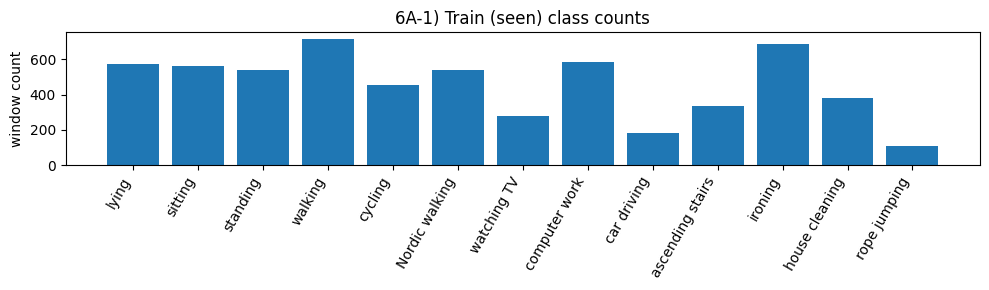

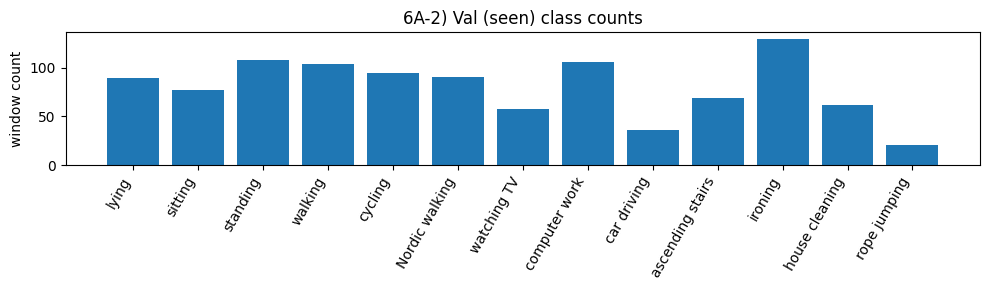

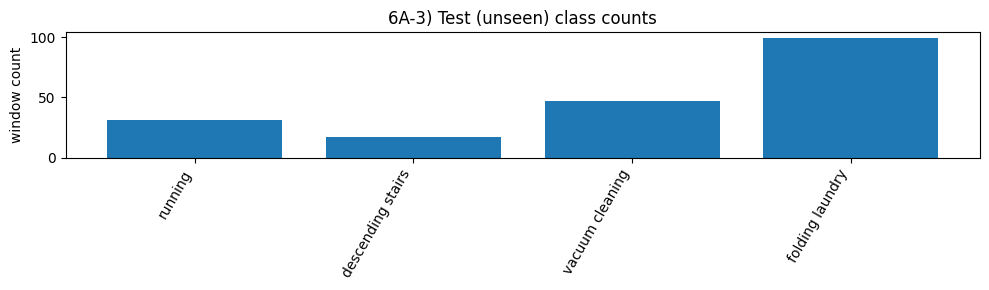

In [13]:
def plot_counts(y_arr, title):
    vc = pd.Series(y_arr).value_counts().sort_index()
    names = [ACTIVITY_MAP.get(i, str(i)) for i in vc.index]
    plt.figure(figsize=(10,3))
    plt.bar(range(len(vc)), vc.values)
    plt.xticks(range(len(vc)), names, rotation=60, ha="right")
    plt.title(title)
    plt.ylabel("window count")
    plt.tight_layout()
    plt.show()

plot_counts(y_tr, "6A-1) Train (seen) class counts")
plot_counts(y_val, "6A-2) Val (seen) class counts")
plot_counts(y_test_u, "6A-3) Test (unseen) class counts")

## 7) Standardize features using train statistics

We compute mean/std from **train seen windows only** and standardize train/val/test.
This prevents test leakage.

In [14]:
eps = 1e-6
mu = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
sd = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps

X_tr_n = (X_tr - mu) / sd
X_val_n = (X_val - mu) / sd
X_test_u_n = (X_test_u - mu) / sd

print("Standardized shapes:", X_tr_n.shape, X_val_n.shape, X_test_u_n.shape)


Standardized shapes: (5938, 500, 32) (1047, 500, 32) (194, 1000, 32)


## 8) Build transformer label prototypes (Sentence‑BERT)

We embed each class description into a fixed vector.
These are **prototypes** used by ZSL.

Notes:
- Prototypes are **fixed** (no training)
- The time-series model is trained to output embeddings that align with these prototypes

In [15]:
# If missing, install once:
# !pip -q install sentence-transformers

from sentence_transformers import SentenceTransformer
st_model = SentenceTransformer("all-MiniLM-L6-v2")

class_ids = sorted(ALL_LABELS)
texts = [LABEL_TEXT.get(cid, ACTIVITY_MAP.get(cid, str(cid))) for cid in class_ids]

S = st_model.encode(texts, normalize_embeddings=True).astype(np.float32)  # [C,D]
SEM_DIM = S.shape[1]
row = {cid:i for i, cid in enumerate(class_ids)}

print("Prototype matrix S:", S.shape, "| embedding dim:", SEM_DIM)
print("Example label text:", class_ids[0], "→", texts[0])

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Prototype matrix S: (18, 384) | embedding dim: 384
Example label text: 1 → lying quietly while doing nothing; small movements allowed (e.g., changing posture)


### Visualisation 8A — Prototype similarity heatmap

If some prototypes are extremely similar, those classes will be hard to separate in ZSL.

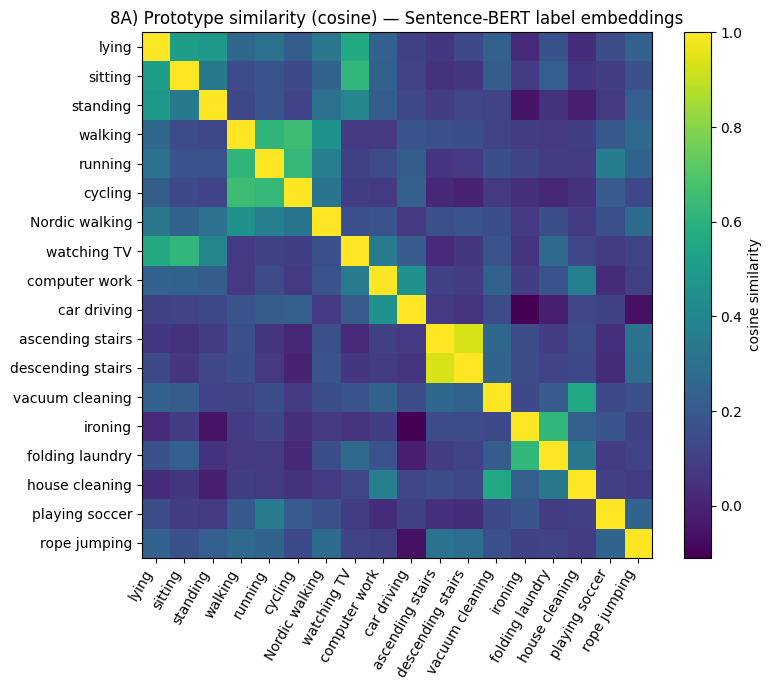

In [16]:
sim = S @ S.T
plt.figure(figsize=(8,7))
plt.imshow(sim, aspect="auto")
plt.title("8A) Prototype similarity (cosine) — Sentence-BERT label embeddings")
plt.xticks(range(len(class_ids)), [ACTIVITY_MAP.get(i,i) for i in class_ids], rotation=60, ha="right")
plt.yticks(range(len(class_ids)), [ACTIVITY_MAP.get(i,i) for i in class_ids])
plt.colorbar(label="cosine similarity")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


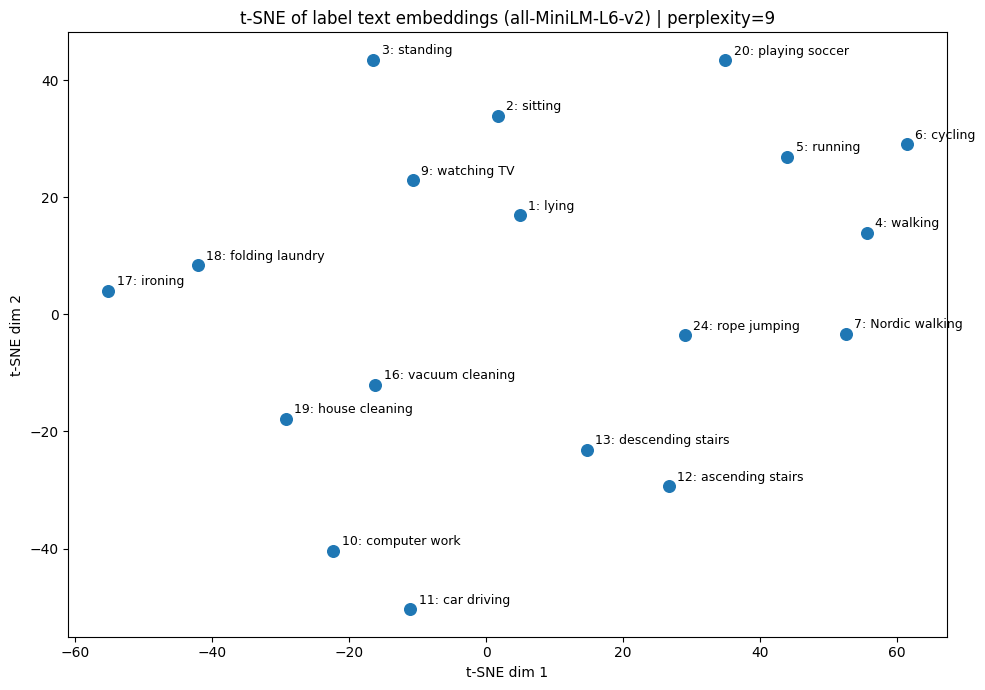

In [33]:
# If missing, install once:
# !pip -q install sentence-transformers scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

# --- your dicts (ACTIVITY_MAP, LABEL_TEXT) already defined above ---

# Labels to embed (all labels present in either dict)
ALL_LABELS = sorted(set(ACTIVITY_MAP.keys()) | set(LABEL_TEXT.keys()))

# Use LABEL_TEXT if present; otherwise fall back to ACTIVITY_MAP name; otherwise label id as str
texts = [LABEL_TEXT.get(cid, ACTIVITY_MAP.get(cid, str(cid))) for cid in ALL_LABELS]

# Sentence-Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
E = st_model.encode(texts, normalize_embeddings=True).astype(np.float32)  # [C, D]

# t-SNE (pick a small perplexity since C is small)
perplexity = min(10, max(2, len(ALL_LABELS)//2))
Z = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    random_state=42
).fit_transform(E)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1], s=70)

for i, cid in enumerate(ALL_LABELS):
    name = ACTIVITY_MAP.get(cid, str(cid))
    plt.annotate(f"{cid}: {name}", (Z[i, 0], Z[i, 1]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)

plt.title(f"t-SNE of label text embeddings (all-MiniLM-L6-v2) | perplexity={perplexity}")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()


## 9) Datasets & DataLoaders

We use `num_workers=0` for macOS/Jupyter reliability.

In [32]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 256 if DEVICE == "cuda" else 64

train_loader = DataLoader(WindowDataset(X_tr_n, y_tr), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=True)
val_loader   = DataLoader(WindowDataset(X_val_n, y_val), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(WindowDataset(X_test_u, y_test_u), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))

## 10) Time-series model: TCN (fast & strong)

Why TCN:
- Convolutions are fast (GPU-friendly)
- Dilations give long receptive field
- Works well for IMU time-series

Output:
- a **unit-normalized** embedding vector in the same space as label prototypes.

In [18]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, d=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * d // 2
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=k, dilation=d, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=k, dilation=d, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.net(x) + self.res(x)

class TCNEncoder(nn.Module):
    def __init__(self, n_features, channels=(64, 96, 128), k=5, dropout=0.1):
        super().__init__()
        blocks = []
        in_ch = n_features
        d = 1
        for out_ch in channels:
            blocks.append(TCNBlock(in_ch, out_ch, k=k, d=d, dropout=dropout))
            in_ch = out_ch
            d *= 2
        self.tcn = nn.Sequential(*blocks)
    def forward(self, x):
        x = x.transpose(1,2)  # [B,F,T]
        x = self.tcn(x)       # [B,C,T]
        return x.mean(dim=2)  # global avg pool over time

class ZSLModel(nn.Module):
    def __init__(self, n_features, emb_dim, enc_channels=(64,96,128), proj=256, dropout=0.1):
        super().__init__()
        self.enc = TCNEncoder(n_features, channels=enc_channels, k=5, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(enc_channels[-1], proj),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(proj, emb_dim),
        )
    def forward(self, x):
        z = self.enc(x)
        y = self.head(z)
        return y / (y.norm(dim=1, keepdim=True) + 1e-8)

model = ZSLModel(n_features=X_tr_n.shape[-1], emb_dim=SEM_DIM).to(DEVICE)
print("Params (M):", sum(p.numel() for p in model.parameters())/1e6)

Params (M): 0.403936


## 11) Contrastive training (InfoNCE / cross-entropy over prototypes)

For each train window:
- model predicts an embedding `e`
- compute similarities to **all** label prototypes `S`
- cross-entropy pushes `e` to match the correct prototype (seen label)

We log each epoch:
- train loss
- val seen accuracy (nearest prototype among SEEN)
- test unseen ZSL accuracy (nearest prototype among UNSEEN)  ← *monitor generalization*
- test unseen ZSL accuracy after **pseudo-label prototype refinement**

In [19]:
S_t = torch.tensor(S, dtype=torch.float32, device=DEVICE)  # [C,D]

def logits(pred_emb, proto_emb, temperature=0.07):
    return (pred_emb @ proto_emb.T) / temperature

def eval_nearest(model, loader, candidate_ids):
    model.eval()
    cand_idx = torch.tensor([row[c] for c in candidate_ids], device=DEVICE)
    proto = S_t[cand_idx]  # [K,D]
    yt, yp = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            e = model(xb)
            sims = e @ proto.T
            pred_k = torch.argmax(sims, dim=1).cpu().numpy()
            pred_lab = np.array([candidate_ids[i] for i in pred_k], dtype=np.int64)
            yt.append(yb.numpy())
            yp.append(pred_lab)
    yt = np.concatenate(yt) if yt else np.array([], dtype=np.int64)
    yp = np.concatenate(yp) if yp else np.array([], dtype=np.int64)
    acc = float((yt == yp).mean()) if len(yt) else float("nan")
    return acc, yt, yp

@torch.no_grad()
def collect_embeddings(model, loader, max_points=None):
    model.eval()
    E, Y = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        e = model(xb).cpu().numpy()
        E.append(e)
        Y.append(yb.numpy())
        if max_points and sum(len(a) for a in E) >= max_points:
            break
    E = np.concatenate(E, axis=0)
    Y = np.concatenate(Y, axis=0)
    if max_points:
        E, Y = E[:max_points], Y[:max_points]
    return E, Y

def refine_prototypes_pseudo(E, y_pred, proto_ids, proto_emb, alpha=0.6):
    # Use predicted labels (pseudo-labels) to compute centroids.
    refined = []
    for i, cid in enumerate(proto_ids):
        mask = (y_pred == cid)
        if mask.sum() == 0:
            refined.append(proto_emb[i])
            continue
        centroid = E[mask].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-8)
        p = alpha * proto_emb[i] + (1 - alpha) * centroid
        p = p / (np.linalg.norm(p) + 1e-8)
        refined.append(p)
    return np.stack(refined, axis=0)

def zsl_accuracy_with_refinement(model, loader, unseen_ids, alpha=0.6):
    # 1) baseline predictions on unseen
    base_acc, y_true, y_pred = eval_nearest(model, loader, unseen_ids)
    # 2) collect embeddings for unseen set
    E, _ = collect_embeddings(model, loader)
    # 3) refine prototypes using pseudo labels
    proto_unseen = np.stack([S[row[c]] for c in unseen_ids], axis=0)
    refined = refine_prototypes_pseudo(E, y_pred, unseen_ids, proto_unseen, alpha=alpha)
    # 4) re-predict with refined prototypes
    sims = E @ refined.T
    pred2 = np.array([unseen_ids[i] for i in sims.argmax(axis=1)], dtype=np.int64)
    acc2 = float((pred2 == y_true).mean()) if len(y_true) else float("nan")
    return base_acc, acc2

# EPOCHS = 15
# LR = 2e-3
# TEMP = 0.07
# ALPHA_REFINE = 0.6

# opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# history = {
#     "train_loss": [],
#     "val_seen_acc": [],
#     "test_unseen_acc": [],
#     "test_unseen_acc_refined": [],
# }

seen_ids = SEEN
unseen_ids = UNSEEN

# for ep in range(1, EPOCHS+1):
#     model.train()
#     running, n = 0.0, 0

#     for xb, yb in train_loader:
#         xb = xb.to(DEVICE)
#         # map raw label ids -> prototype indices
#         tgt = torch.tensor([row[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long)

#         e = model(xb)
#         lg = logits(e, S_t, temperature=TEMP)
#         loss = nn.functional.cross_entropy(lg, tgt)

#         opt.zero_grad(set_to_none=True)
#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         opt.step()

#         running += float(loss.item()) * len(xb)
#         n += len(xb)

    # train_loss = running / max(n,1)
    # val_acc, _, _ = eval_nearest(model, val_loader, seen_ids)
    # test_acc, test_acc_ref = zsl_accuracy_with_refinement(model, test_loader, unseen_ids, alpha=ALPHA_REFINE)

    # history["train_loss"].append(train_loss)
    # history["val_seen_acc"].append(val_acc)
    # history["test_unseen_acc"].append(test_acc)
    # history["test_unseen_acc_refined"].append(test_acc_ref)

    # print(
    #     f"Epoch {ep:02d} | "
    #     f"train_loss={train_loss:.4f} | "
    #     f"val_seen_acc={val_acc:.3f} | "
    #     f"ZSL_unseen={test_acc:.3f} | "
    #     f"ZSL_unseen_refined={test_acc_ref:.3f}"
    # )
    
EPOCHS = 20          # max epochs; early stopping usually stops earlier
LR = 2e-3
TEMP = 0.07
ALPHA_REFINE = 0.6

EARLY_STOP_METRIC = "refined"  # "refined" or "baseline"
PATIENCE = 6
MIN_DELTA = 1e-4

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_score = -1.0
best_state = None
bad_epochs = 0

history = {"train_loss": [], "val_seen_acc": [], "zsl_unseen": [], "zsl_unseen_ref": []}

for ep in range(1, EPOCHS+1):
    model.train()
    running, n = 0.0, 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)

        # map label IDs -> row indices in prototype matrix
        tgt = torch.tensor([row[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long)

        e = model(xb)
        lg = (e @ S_t.T) / TEMP
        loss = nn.functional.cross_entropy(lg, tgt)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        running += float(loss.item()) * len(xb)
        n += len(xb)

    train_loss = running / max(n, 1)

    # seen validation accuracy
    val_acc, _, _ = eval_nearest(model, val_loader, SEEN)

    # unseen ZSL baseline + refined (pseudo-label refinement)
    zsl_base, zsl_ref = zsl_accuracy_with_refinement(model, test_loader, UNSEEN, alpha=ALPHA_REFINE)

    history["train_loss"].append(train_loss)
    history["val_seen_acc"].append(val_acc)
    history["zsl_unseen"].append(zsl_base)
    history["zsl_unseen_ref"].append(zsl_ref)

    score = zsl_ref if EARLY_STOP_METRIC == "refined" else zsl_base

    print(
        f"Epoch {ep:02d} | train_loss={train_loss:.4f} | val_seen_acc={val_acc:.3f} | "
        f"ZSL_unseen={zsl_base:.3f} | ZSL_unseen_refined={zsl_ref:.3f} | "
        f"monitor={EARLY_STOP_METRIC}:{score:.3f}"
    )

    # --- early stopping ---
    if score > best_score + MIN_DELTA:
        best_score = score
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {ep}. Best {EARLY_STOP_METRIC} ZSL={best_score:.3f}")
            break

# restore best weights
if best_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print("Restored best checkpoint. Best monitored ZSL:", best_score)

Epoch 01 | train_loss=0.3290 | val_seen_acc=0.977 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 02 | train_loss=0.1036 | val_seen_acc=0.979 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 03 | train_loss=0.0657 | val_seen_acc=0.973 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 04 | train_loss=0.0614 | val_seen_acc=0.974 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 05 | train_loss=0.0401 | val_seen_acc=0.988 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 06 | train_loss=0.0373 | val_seen_acc=0.980 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Epoch 07 | train_loss=0.0456 | val_seen_acc=0.988 | ZSL_unseen=0.160 | ZSL_unseen_refined=0.160 | monitor=refined:0.160
Early stopping at epoch 7. Best refined ZSL=0.160
Restored best checkpoint. Best monitored ZSL: 0.15979381443298968


In [20]:
seen_ids = SEEN
unseen_ids = UNSEEN

### Visualisation 11A — Training curves

- **train_loss** should decrease
- **val_seen_acc** shows whether the model is learning on seen classes
- **ZSL_unseen** is baseline ZSL performance
- **ZSL_unseen_refined** should be ≥ baseline if refinement helps

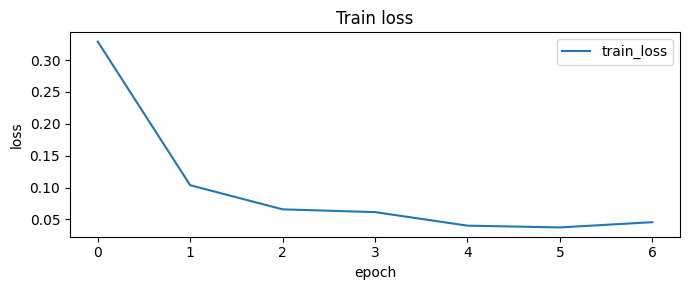

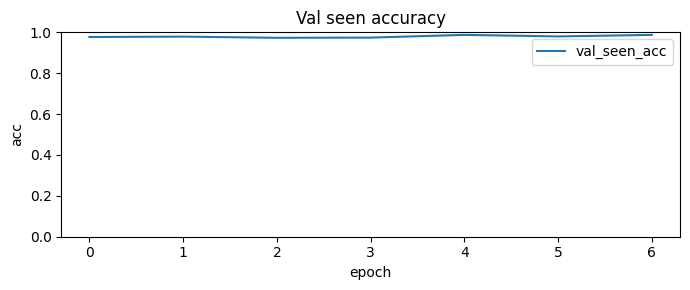

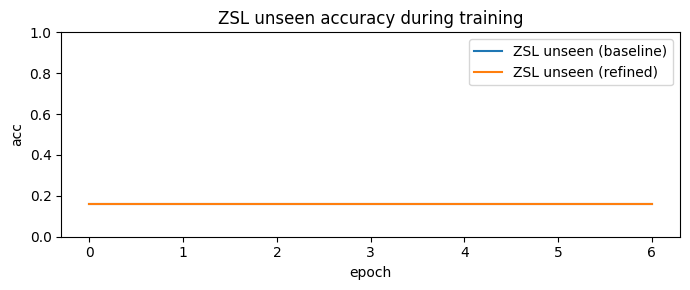

In [21]:
plt.figure(figsize=(7,3))
plt.plot(history["train_loss"], label="train_loss")
plt.title("Train loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3))
plt.plot(history["val_seen_acc"], label="val_seen_acc")
plt.title("Val seen accuracy")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.ylim(0,1)
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3))
plt.plot(history["zsl_unseen"], label="ZSL unseen (baseline)")
plt.plot(history["zsl_unseen_ref"], label="ZSL unseen (refined)")
plt.title("ZSL unseen accuracy during training")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.ylim(0,1)
plt.legend(); plt.tight_layout(); plt.show()


## 12) Final evaluation (after training)

We report:
- baseline ZSL confusion matrix
- refined ZSL confusion matrix
- per-class precision/recall/f1

Note: refined here uses **pseudo-label refinement** (no ground-truth leakage).

In [22]:
# Collect final embeddings once
E_unseen, y_true = collect_embeddings(model, test_loader)

# Baseline prediction
proto_unseen = np.stack([S[row[c]] for c in unseen_ids], axis=0)
pred_base = np.array([unseen_ids[i] for i in (E_unseen @ proto_unseen.T).argmax(axis=1)], dtype=np.int64)

# Refined prediction (pseudo-labels from baseline)
refined = refine_prototypes_pseudo(E_unseen, pred_base, unseen_ids, proto_unseen, alpha=ALPHA_REFINE)
pred_ref = np.array([unseen_ids[i] for i in (E_unseen @ refined.T).argmax(axis=1)], dtype=np.int64)

acc_base = float((pred_base == y_true).mean())
acc_ref  = float((pred_ref == y_true).mean())
print("Final baseline ZSL acc:", acc_base)
print("Final refined  ZSL acc:", acc_ref)

print("\nClassification report (baseline):")
print(classification_report(
    y_true, pred_base,
    labels=unseen_ids,
    target_names=[ACTIVITY_MAP.get(i,str(i)) for i in unseen_ids],
    zero_division=0
))

print("\nClassification report (refined):")
print(classification_report(
    y_true, pred_ref,
    labels=unseen_ids,
    target_names=[ACTIVITY_MAP.get(i,str(i)) for i in unseen_ids],
    zero_division=0
))

Final baseline ZSL acc: 0.15979381443298968
Final refined  ZSL acc: 0.15979381443298968

Classification report (baseline):
                   precision    recall  f1-score   support

          running       0.16      1.00      0.28        31
descending stairs       0.00      0.00      0.00        17
  vacuum cleaning       0.00      0.00      0.00        47
  folding laundry       0.00      0.00      0.00        99

         accuracy                           0.16       194
        macro avg       0.04      0.25      0.07       194
     weighted avg       0.03      0.16      0.04       194


Classification report (refined):
                   precision    recall  f1-score   support

          running       0.16      1.00      0.28        31
descending stairs       0.00      0.00      0.00        17
  vacuum cleaning       0.00      0.00      0.00        47
  folding laundry       0.00      0.00      0.00        99

         accuracy                           0.16       194
        macr

### Visualisation 12A — Confusion matrices (baseline vs refined)

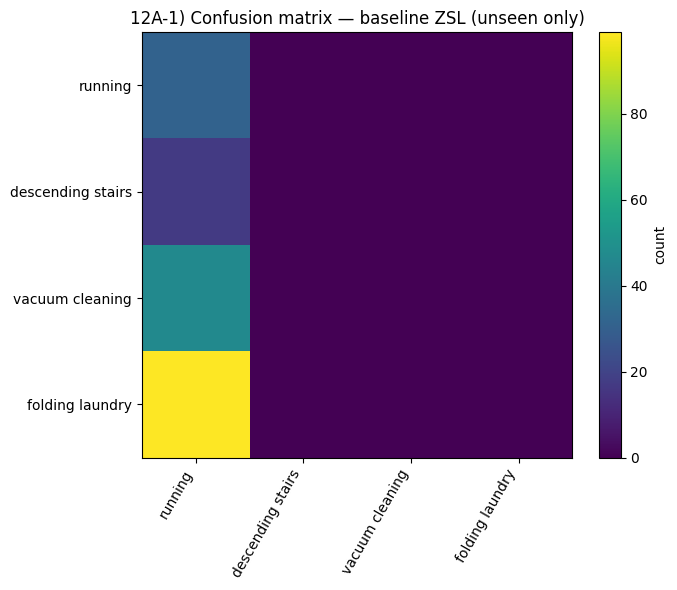

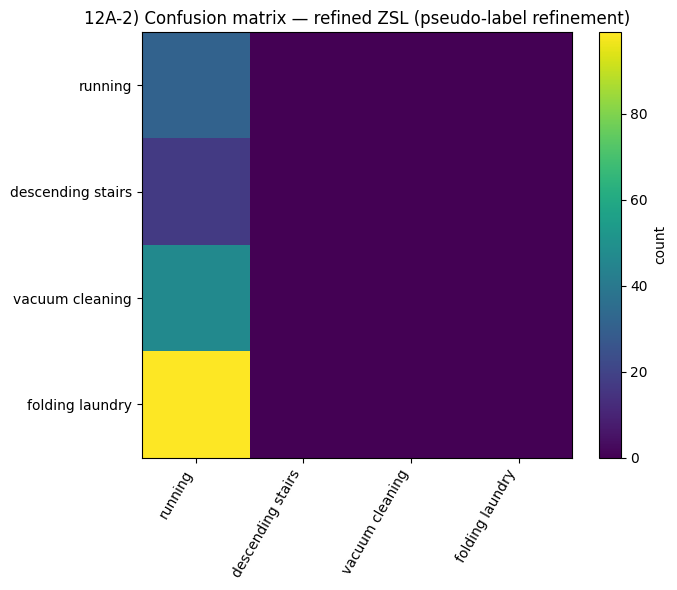

In [23]:
names = [ACTIVITY_MAP.get(i,str(i)) for i in unseen_ids]

cm_base = confusion_matrix(y_true, pred_base, labels=unseen_ids)
cm_ref  = confusion_matrix(y_true, pred_ref,  labels=unseen_ids)

plt.figure(figsize=(7,6))
plt.imshow(cm_base, aspect="auto")
plt.title("12A-1) Confusion matrix — baseline ZSL (unseen only)")
plt.xticks(range(len(names)), names, rotation=60, ha="right")
plt.yticks(range(len(names)), names)
plt.colorbar(label="count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.imshow(cm_ref, aspect="auto")
plt.title("12A-2) Confusion matrix — refined ZSL (pseudo-label refinement)")
plt.xticks(range(len(names)), names, rotation=60, ha="right")
plt.yticks(range(len(names)), names)
plt.colorbar(label="count")
plt.tight_layout()
plt.show()

## 13) t‑SNE: unseen embeddings + prototypes in the SAME chart

You asked specifically for:
- plot label embeddings and unseen data embeddings together

We show:
- **dots:** unseen window embeddings (colored by true label)
- **stars (⭐):** original label prototypes
- **X:** refined prototypes

/var/folders/vg/k0ywmhzs795fbmcwh9xnh2l40000gn/T/ipykernel_1512/2608818536.py:34: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.tight_layout()
/Users/anikghosh/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


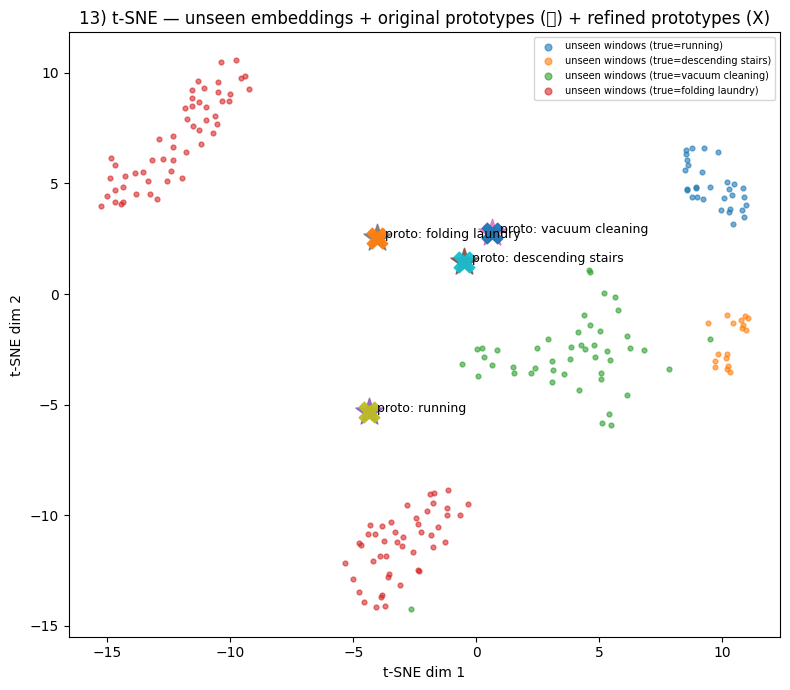

In [31]:
# Use a subset for speed
max_points = min(2500, len(E_unseen))
idx = np.random.choice(len(E_unseen), size=max_points, replace=False) if len(E_unseen) > max_points else np.arange(len(E_unseen))

E_sub = E_unseen[idx]
y_sub = y_true[idx]

X_tsne = np.vstack([E_sub, proto_unseen, refined])
Z = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=SEED).fit_transform(X_tsne)

Z_pts = Z[:len(E_sub)]
Z_star = Z[len(E_sub):len(E_sub)+len(unseen_ids)]
Z_x = Z[len(E_sub)+len(unseen_ids):]

plt.figure(figsize=(8,7))
for cid in unseen_ids:
    m = (y_sub == cid)
    if m.sum() == 0:
        continue
    plt.scatter(Z_pts[m,0], Z_pts[m,1], s=12, alpha=0.6, label=f"unseen windows (true={ACTIVITY_MAP.get(cid,cid)})")

for i, cid in enumerate(unseen_ids):
    plt.scatter(Z_star[i,0], Z_star[i,1], marker="*", s=420, alpha=0.95)
    plt.text(Z_star[i,0], Z_star[i,1], f"  proto: {ACTIVITY_MAP.get(cid,cid)}", fontsize=9)

for i, cid in enumerate(unseen_ids):
    plt.scatter(Z_x[i,0], Z_x[i,1], marker="X", s=220, alpha=0.95)
    plt.text(Z_x[i,0], Z_x[i,1], f"  ", fontsize=9)

plt.title("13) t-SNE — unseen embeddings + original prototypes (⭐) + refined prototypes (X)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend(fontsize=7, loc="best", markerscale=1.4)
plt.tight_layout()
plt.show()

## 15) Why ZSL is difficult on PAMAP2 (diagnostics)

ZSL on sensor/time-series HAR is often difficult because:

- **Semantic prototypes are weak**: label text embeddings may not capture fine-grained motion differences (e.g., walking vs. ascending stairs).
- **High class overlap** in sensor space: many activities share similar IMU patterns.
- **Intra-class variability**: differences across subjects, devices, and intensity.
- **Seen-class bias**: the embedding model is trained only on seen classes, so unseen samples may get pulled toward seen-like regions.

Below are *diagnostics* to (1) visualise overlap/ambiguity and (2) check for prediction collapse.


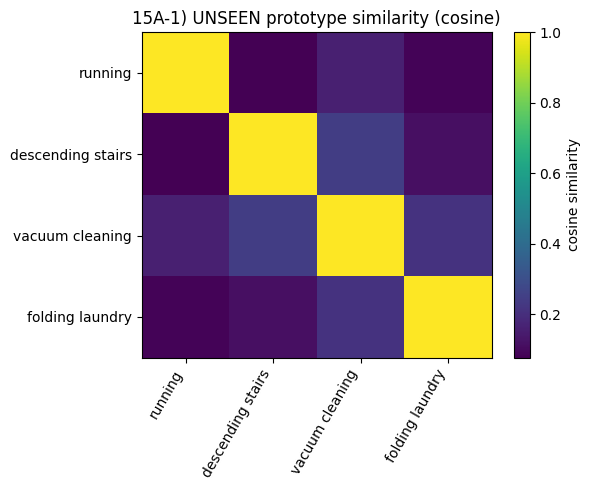

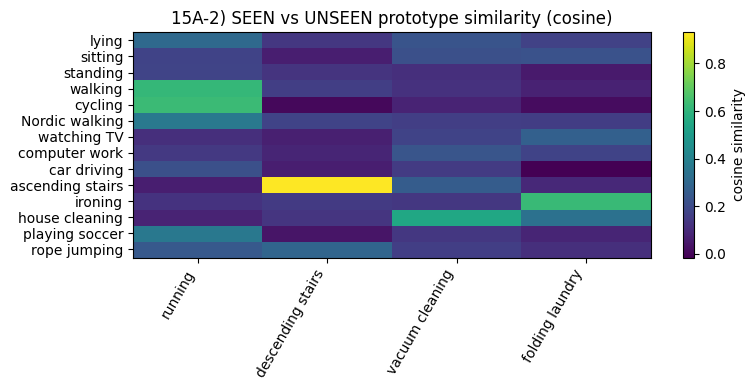

In [25]:
# 15A) Prototype similarity focused on UNSEEN (and SEEN vs UNSEEN)
# High prototype similarity among unseen classes means the semantic space itself makes them hard to separate.

# --- Alias label lists to avoid name mismatches ---
# Prefer the notebook's canonical variables if they exist; otherwise fall back to alternatives.
if 'UNSEEN' not in globals() and 'unseen_ids' in globals():
    UNSEEN = list(unseen_ids)
if 'SEEN' not in globals() and 'seen_ids' in globals():
    SEEN = list(seen_ids)
if 'ACTIVITY_MAP' not in globals():
    ACTIVITY_MAP = {}

if 'S' in globals() and 'row' in globals() and 'SEEN' in globals() and 'UNSEEN' in globals():
    unseen_idx = [row[c] for c in UNSEEN]
    seen_idx   = [row[c] for c in SEEN]

    S_un = S[unseen_idx]
    S_se = S[seen_idx]

    sim_un = S_un @ S_un.T
    sim_cross = S_se @ S_un.T

    names_un = [ACTIVITY_MAP.get(i, str(i)) for i in UNSEEN]
    names_se = [ACTIVITY_MAP.get(i, str(i)) for i in SEEN]

    plt.figure(figsize=(6,5))
    plt.imshow(sim_un, aspect='auto')
    plt.title("15A-1) UNSEEN prototype similarity (cosine)")
    plt.xticks(range(len(names_un)), names_un, rotation=60, ha='right')
    plt.yticks(range(len(names_un)), names_un)
    plt.colorbar(label="cosine similarity")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.imshow(sim_cross, aspect='auto')
    plt.title("15A-2) SEEN vs UNSEEN prototype similarity (cosine)")
    plt.xticks(range(len(names_un)), names_un, rotation=60, ha='right')
    plt.yticks(range(len(names_se)), names_se)
    plt.colorbar(label="cosine similarity")
    plt.tight_layout()
    plt.show()
else:
    print("Run earlier cells first (prototypes S, row, SEEN/UNSEEN).")

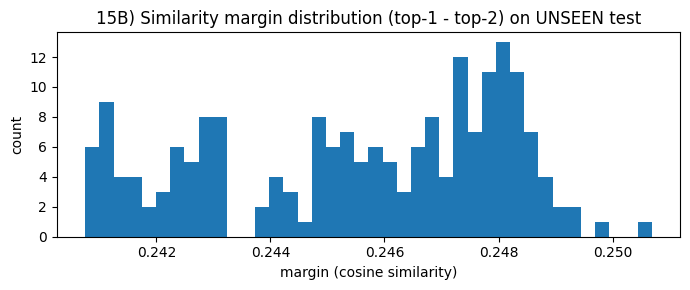

Margin summary:
  mean: 0.24553322792053223
  median: 0.24599885940551758
  10th percentile: 0.2415480613708496


In [26]:
# 15B) Ambiguity via similarity margins (top-1 vs top-2)
# Low margin => model finds multiple unseen classes equally plausible => overlap/weak semantics.

# --- Alias label lists to avoid name mismatches ---
# Prefer the notebook's canonical variables if they exist; otherwise fall back to alternatives.
if 'UNSEEN' not in globals() and 'unseen_ids' in globals():
    UNSEEN = list(unseen_ids)
if 'SEEN' not in globals() and 'seen_ids' in globals():
    SEEN = list(seen_ids)
if 'ACTIVITY_MAP' not in globals():
    ACTIVITY_MAP = {}

if 'E_unseen' in globals() and 'UNSEEN' in globals() and 'S' in globals() and 'row' in globals():
    proto_unseen = np.stack([S[row[c]] for c in UNSEEN], axis=0)  # [K,D]
    sims = E_unseen @ proto_unseen.T  # [N,K]
    top2 = np.sort(sims, axis=1)[:, -2:]
    margin = top2[:, 1] - top2[:, 0]

    plt.figure(figsize=(7,3))
    plt.hist(margin, bins=40)
    plt.title("15B) Similarity margin distribution (top-1 - top-2) on UNSEEN test")
    plt.xlabel("margin (cosine similarity)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

    print("Margin summary:")
    print("  mean:", float(margin.mean()))
    print("  median:", float(np.median(margin)))
    print("  10th percentile:", float(np.percentile(margin, 10)))
else:
    print("Run the final evaluation cell first to create E_unseen.")

[baseline ZSL] top predicted class: running | top_frac=1.000 | norm_entropy=-0.000
⚠️ Warning: predictions are heavily collapsed to one unseen class. Consider calibration/refinement and stronger semantics.


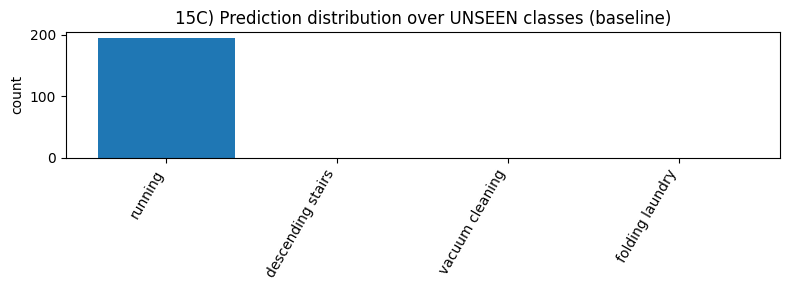

In [27]:
import pandas as pd
# 15C) Prediction collapse check
# Ensures the ZSL model isn't predicting (almost) everything as a single unseen class.

# --- Alias label lists to avoid name mismatches ---
# Prefer the notebook's canonical variables if they exist; otherwise fall back to alternatives.
if 'UNSEEN' not in globals() and 'unseen_ids' in globals():
    UNSEEN = list(unseen_ids)
if 'SEEN' not in globals() and 'seen_ids' in globals():
    SEEN = list(seen_ids)
if 'ACTIVITY_MAP' not in globals():
    ACTIVITY_MAP = {}

def collapse_report(y_pred, label_ids, name="pred"):
    vc = pd.Series(y_pred).value_counts()
    total = vc.sum()
    top_lab = int(vc.index[0]) if len(vc) else None
    top_frac = float(vc.iloc[0] / total) if total > 0 else float('nan')

    # Normalised entropy of prediction distribution
    p = (vc / total).values if total > 0 else np.array([])
    ent = -np.sum(p * np.log(p + 1e-12)) if len(p) else 0.0
    ent_norm = float(ent / np.log(len(label_ids))) if len(label_ids) > 1 else 0.0

    print(f"[{name}] top predicted class: {ACTIVITY_MAP.get(top_lab, top_lab)} | top_frac={top_frac:.3f} | norm_entropy={ent_norm:.3f}")
    return top_frac, ent_norm

if 'pred_base' in globals() and 'UNSEEN' in globals():
    top_frac, ent_norm = collapse_report(pred_base, UNSEEN, name="baseline ZSL")
    # Heuristic warning: >80% to one class is often a collapse
    if top_frac > 0.80:
        print("⚠️ Warning: predictions are heavily collapsed to one unseen class. Consider calibration/refinement and stronger semantics.")

    # Plot histogram
    names_un = [ACTIVITY_MAP.get(i, str(i)) for i in UNSEEN]
    vc = pd.Series(pred_base).value_counts().reindex(UNSEEN).fillna(0).astype(int)
    plt.figure(figsize=(8,3))
    plt.bar(range(len(UNSEEN)), vc.values)
    plt.xticks(range(len(UNSEEN)), names_un, rotation=60, ha='right')
    plt.title("15C) Prediction distribution over UNSEEN classes (baseline)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("Run the final evaluation cell first to create pred_base.")

## 16) Impact of SEEN vs UNSEEN class ratio (controlled experiment)

To study how ZSL changes when you vary the **number of unseen classes**, we can:

1) Sample an UNSEEN set of size *k* (different ratios)  
2) Rebuild the splits (train/val seen only; test unseen only) using the same subject-holdout logic  
3) Retrain a fresh ZSL model for a small number of epochs (quick diagnostic run)  
4) Record ZSL unseen accuracy and (optionally) confusion / margin stats

Notes:
- This is a *diagnostic* experiment: keep epochs small to compare trends.
- For stability, we repeat each ratio multiple times with different random UNSEEN selections.


In [28]:
# --- Guards / aliases to avoid variable name mismatches ---
# Expect windowed arrays: X_trw, y_trw, X_tew, y_tew and metadata: meta_tr, meta_te
missing = []
for _name in ['X_trw','y_trw','X_tew','y_tew','meta_tr','meta_te','S','row','WindowDataset','ZSLModel','eval_nearest','SEM_DIM','BATCH_SIZE','DEVICE']:
    if _name not in globals():
        missing.append(_name)
if missing:
    raise NameError(f"Missing required variables for ratio-sweep section: {missing}")


import random
from IPython.display import display

def make_splits_for_unseen(unseen_list, val_frac=0.15, seed=SEED):
    rng = np.random.default_rng(seed)

    ALL_LABELS_local = sorted(set(y_trw.tolist() + y_tew.tolist()))
    unseen_list = [l for l in unseen_list if l in ALL_LABELS_local]
    seen_list = [l for l in ALL_LABELS_local if l not in unseen_list]

    # subject split (same as earlier)
    subjects = sorted(meta_tr["subject"].unique())
    test_subjects = subjects[-2:] if len(subjects) >= 3 else subjects[-1:]

    is_test_subj_tr = meta_tr["subject"].isin(test_subjects).values
    is_test_subj_te = meta_te["subject"].isin(test_subjects).values

    # Train/Val: non-test subjects, SEEN only
    X_train_all, y_train_all = X_trw[~is_test_subj_tr], y_trw[~is_test_subj_tr]
    train_seen_mask = np.isin(y_train_all, seen_list)
    X_seen, y_seen = X_train_all[train_seen_mask], y_train_all[train_seen_mask]

    perm = rng.permutation(len(X_seen))
    n_val = int(len(perm) * val_frac)
    val_idx, tr_idx = perm[:n_val], perm[n_val:]
    X_tr, y_tr = X_seen[tr_idx], y_seen[tr_idx]
    X_val, y_val = X_seen[val_idx], y_seen[val_idx]

    # Test: test subjects, UNSEEN only
    X_test_all, y_test_all = X_tew[is_test_subj_te], y_tew[is_test_subj_te]
    test_unseen_mask = np.isin(y_test_all, unseen_list)
    X_test_u, y_test_u = X_test_all[test_unseen_mask], y_test_all[test_unseen_mask]

    return seen_list, unseen_list, (X_tr, y_tr, X_val, y_val, X_test_u, y_test_u)

def standardize_from_train(X_tr, X_val, X_test_u):
    eps = 1e-6
    mu = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
    sd = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps
    return (X_tr - mu)/sd, (X_val - mu)/sd, (X_test_u - mu)/sd

def quick_train_and_eval(seen_list, unseen_list, data_tuple, epochs=5, lr=2e-3, temp=0.07, max_train_windows=6000):
    X_tr, y_tr, X_val, y_val, X_test_u, y_test_u = data_tuple

    # Optional subsample for speed
    if len(X_tr) > max_train_windows:
        idx = np.random.choice(len(X_tr), size=max_train_windows, replace=False)
        X_tr, y_tr = X_tr[idx], y_tr[idx]

    X_tr_n, X_val_n, X_test_u_n = standardize_from_train(X_tr, X_val, X_test_u)

    train_loader = DataLoader(WindowDataset(X_tr_n, y_tr), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader   = DataLoader(WindowDataset(X_val_n, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(WindowDataset(X_test_u_n, y_test_u), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = ZSLModel(in_ch=X_tr_n.shape[-1], emb_dim=SEM_DIM).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # Prototype tensor
    S_t = torch.tensor(S, dtype=torch.float32, device=DEVICE)

    def logits(pred_emb, proto_emb, temperature=temp):
        return (pred_emb @ proto_emb.T) / temperature

    # Training: CE over prototypes for SEEN labels only
    for ep in range(1, epochs+1):
        model.train()
        running, n = 0.0, 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            tgt = torch.tensor([row[int(l)] for l in yb.numpy()], device=DEVICE, dtype=torch.long)
            e = model(xb)
            lg = logits(e, S_t, temperature=temp)
            loss = nn.functional.cross_entropy(lg, tgt)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += float(loss.item()) * len(xb)
            n += len(xb)

        # Quick val seen acc
        val_acc, _, _ = eval_nearest(model, val_loader, seen_list)
        print(f"  ep {ep:02d} | train_loss={running/max(n,1):.4f} | val_seen_acc={val_acc:.3f}")

    # Final unseen-only ZSL acc
    test_acc, y_true, y_pred = eval_nearest(model, test_loader, unseen_list)

    # Collapse report
    top_frac, ent_norm = collapse_report(y_pred, unseen_list, name=f"ratio-run (k={len(unseen_list)})")

    return test_acc, top_frac, ent_norm

# 16A) Run ratio sweep (quick diagnostic)
if 'y_trw' in globals() and 'meta_tr' in globals() and 'ZSLModel' in globals():
    ratios = [0.2, 0.3, 0.4]          # fraction of labels used as UNSEEN
    repeats = 3                      # repeat to reduce randomness
    epochs = 5                       # keep small; increase for final experiments

    ALL_LABELS_local = sorted(set(y_trw.tolist() + y_tew.tolist()))
    results = []

    for r in ratios:
        k = max(1, int(round(len(ALL_LABELS_local) * r)))
        for rep in range(repeats):
            unseen = random.sample(ALL_LABELS_local, k=k)
            seen_list, unseen_list, data_tuple = make_splits_for_unseen(unseen, seed=SEED + rep)

            # Skip if test set too small (can happen if selected unseen labels are rare in held-out subjects)
            if len(data_tuple[-1]) < 200:
                print(f"Skipping ratio={r:.2f}, rep={rep} (too few unseen test windows: {len(data_tuple[-1])})")
                continue

            print(f"\n=== ratio={r:.2f} | k={k} | rep={rep} ===")
            acc_u, top_frac, ent_norm = quick_train_and_eval(seen_list, unseen_list, data_tuple, epochs=epochs)
            results.append({"ratio_unseen": r, "k_unseen": k, "rep": rep, "zsl_unseen_acc": acc_u, "top_frac": top_frac, "norm_entropy": ent_norm})

    df = pd.DataFrame(results)
    display(df.sort_values(["ratio_unseen","rep"]))

    if len(df):
        plt.figure(figsize=(7,3))
        for r in sorted(df["ratio_unseen"].unique()):
            sub = df[df["ratio_unseen"]==r]
            plt.scatter([r]*len(sub), sub["zsl_unseen_acc"])
        plt.title("16A) ZSL unseen accuracy vs unseen-class ratio (scatter over repeats)")
        plt.xlabel("unseen-class ratio")
        plt.ylabel("ZSL unseen acc")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7,3))
        for r in sorted(df['ratio_unseen'].unique()):
            sub = df[df['ratio_unseen']==r]
            plt.scatter([r]*len(sub), sub["top_frac"])
        plt.title("16B) Prediction collapse indicator (top class fraction) vs unseen-class ratio")
        plt.xlabel("unseen-class ratio")
        plt.ylabel("top predicted class fraction")
        plt.ylim(0,1)
        plt.tight_layout()
        plt.show()
else:
    print("Run earlier cells first (windowed data, prototypes, model classes).")



=== ratio=0.20 | k=4 | rep=0 ===


TypeError: ZSLModel.__init__() got an unexpected keyword argument 'in_ch'

## 14) What to tweak (practical knobs)

If you want to push accuracy higher, try in this order:

1. `PURITY_THRESH`: 0.85 → 0.9 (cleaner windows, fewer samples)
2. Longer inference windows:
   - set `WINDOW_SIZE_TRAIN=500` but create a separate `WINDOW_SIZE_TEST=1000`
3. Prototype refinement strength `ALPHA_REFINE`: try 0.5, 0.6, 0.7
4. Label texts:
   - adjust the household descriptions to emphasize differences (tool vs no tool, walking vs stationary)
5. Encoder capacity:
   - increase TCN channels to (64, 128, 192) if you have GPU

All changes are defensible and easy to explain in your report.